In [37]:
import glob
import os
import numpy as np
import pandas as pd
from aeon.visualisation import plot_critical_difference, create_multi_comparison_matrix
from labicompare.visualization import critical_difference_diagram, generate_mcm
import matplotlib.pyplot as plt

# TSER

In [38]:
my_models = {
    "MultiRocket-TabPFN": '../../tser/' + "results/Tab_multi.csv",
    "tsfresh-TabPFN": '../../tser/' + "results/Tab_tsfresh.csv",
    "C22-TabPFN": '../../tser/' + "results/Tab_c22.csv",
}
metric_name = "RMSE"

In [39]:
results = {}

for model_name, path in my_models.items():
    # 1. Carregar garantindo o índice
    df = pd.read_csv(path, index_col=0)
    df.index = df.index.astype(str)
    
    # 2. Extrair apenas colunas numéricas e calcular a média
    mean_scores = df.select_dtypes(include="number").mean(axis=1)
    results[model_name] = mean_scores

# 3. Criar o DataFrame (Equivalente ao seu template de métricas)
combined = pd.DataFrame(results).dropna()

print("Datasets usados:", len(combined))

Datasets usados: 55


Index(['C22-TabPFN', 'MultiRocket-TabPFN', 'tsfresh-TabPFN'], dtype='object')


/home/gcmerlin/miniconda3/envs/tabs/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/home/gcmerlin/miniconda3/envs/tabs/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


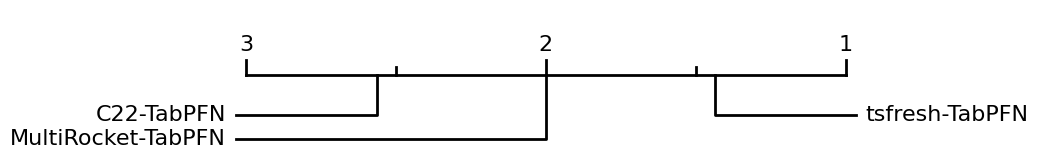

In [40]:
fig = critical_difference_diagram(
    metrics=-combined,
    test='wilcoxon',
    alpha=0.05
)

In [41]:
fig.savefig('figs/tser_intra.pdf', bbox_inches='tight')

/tmp/ipykernel_3153590/3677879981.py:1: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig('figs/tser_intra.pdf', bbox_inches='tight')


In [42]:
model_files = {
    "tsfresh-TabPFN": '../../tser/' + "results/Tab_tsfresh.csv",
    # "MultiROCKET-TabPFN": '../../tser/' + "results/Tab_multi.csv",
    "MiniROCKET": '../../tser/' + "results/MiniROCKET.csv",
    "DrCIF": '../../tser/' + "results/DrCIF.csv",
    "FreshPRINCE": '../../tser/' + "results/FreshPRINCE.csv",
    "InceptionT": '../../tser/' + "results/InceptionT.csv",
    "MultiROCKET": '../../tser/' + "results/MultiROCKET.csv",
    "RotF": '../../tser/' + "results/RotF.csv",
    # "TSF": '../../tser/' + "results/TSF.csv",
    # "RandF": '../../tser/' + "results/RandF.csv",
    # "ResNet": '../../tser/' + "results/ResNet.csv",
    # "Ridge": '../../tser/' + "results/Ridge.csv",
    # "ROCKET": '../../tser/' + "results/ROCKET.csv",
    # "XGBoost": '../../tser/' + "results/XGBoost.csv",
    # "CNN": '../../tser/' + "results/CNN.csv",
}
lower_better = True

In [43]:
results = {}

for model_name, path in model_files.items():
    # 1. Carregar garantindo o índice
    df = pd.read_csv(path, index_col=0)
    df.index = df.index.astype(str)
    
    # 2. Extrair apenas colunas numéricas e calcular a média
    mean_scores = df.select_dtypes(include="number").mean(axis=1)
    results[model_name] = mean_scores

# 3. Criar o DataFrame (Equivalente ao seu template de métricas)
combined = pd.DataFrame(results).dropna()

print("Datasets usados:", len(combined))

Datasets usados: 55


Index(['MultiROCKET', 'RotF', 'InceptionT', 'MiniROCKET', 'FreshPRINCE',
       'DrCIF', 'tsfresh-TabPFN'],
      dtype='object')
[0, 1, 2, 3, 4, 5]


/home/gcmerlin/miniconda3/envs/tabs/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/home/gcmerlin/miniconda3/envs/tabs/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


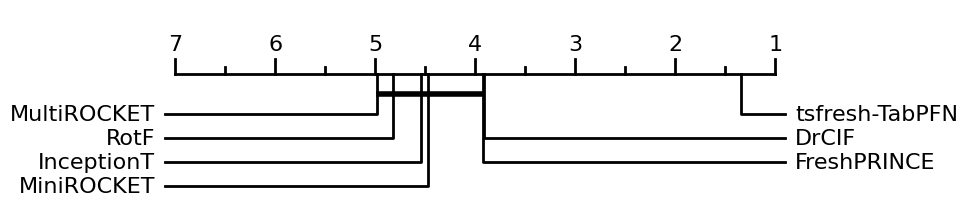

In [44]:
fig = critical_difference_diagram(
    metrics=-combined,
    test='wilcoxon',
    alpha=0.05
)

In [45]:
fig.savefig('figs/tser_bench.pdf', bbox_inches='tight')

/tmp/ipykernel_3153590/2005954545.py:1: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig('figs/tser_bench.pdf', bbox_inches='tight')


Processing FreshPRINCE, DrCIF:   0%|          | 0/3 [00:00<?, ?it/s]         


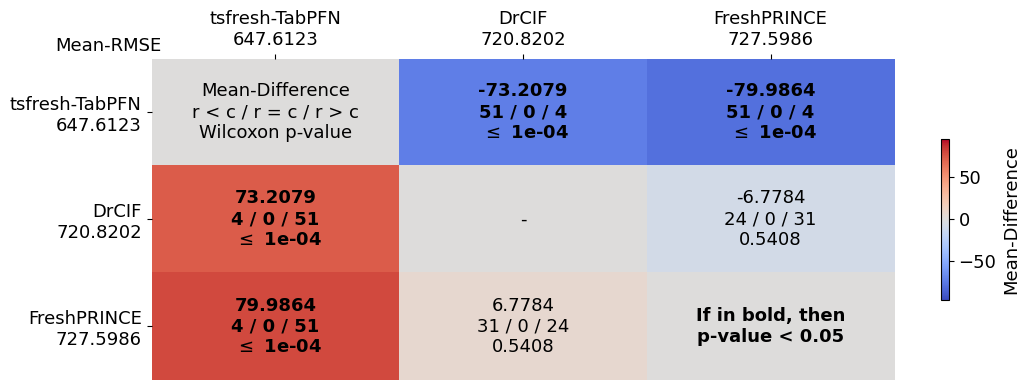

In [46]:
combined = combined[['tsfresh-TabPFN','DrCIF','FreshPRINCE']]

fig = generate_mcm(
    metrics=combined,
    used_statistic="RMSE",
    order_better="increasing",
    order_WinTieLoss="lower",
    win_label="r < c",
    loss_label="r > c",
    tie_label="r = c",
    colormap="coolwarm",
    font_size=13
)

fig.show()

In [47]:
fig.savefig('figs/tser_mcm.pdf', bbox_inches='tight')

# TSC

In [48]:
my_models = {
    "MultiRocket-TabPFN": '../../tsc/' + "results/Tab_multi.csv",
    "tsfresh-TabPFN": '../../tsc/' + "results/Tab_tsfresh.csv",
    "C22-TabPFN": '../../tsc/' + "results/Tab_c22.csv",
}
metric_name = "Accuracy"

In [49]:
results = {}

for model_name, path in my_models.items():
    # 1. Carregar garantindo o índice
    df = pd.read_csv(path, index_col=0)
    df.index = df.index.astype(str)
    
    # 2. Extrair apenas colunas numéricas e calcular a média
    mean_scores = df.select_dtypes(include="number").mean(axis=1)
    results[model_name] = mean_scores

# 3. Criar o DataFrame (Equivalente ao seu template de métricas)
combined = pd.DataFrame(results).dropna()

print("Datasets usados:", len(combined))

Datasets usados: 134


Index(['C22-TabPFN', 'tsfresh-TabPFN', 'MultiRocket-TabPFN'], dtype='object')


/home/gcmerlin/miniconda3/envs/tabs/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/home/gcmerlin/miniconda3/envs/tabs/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


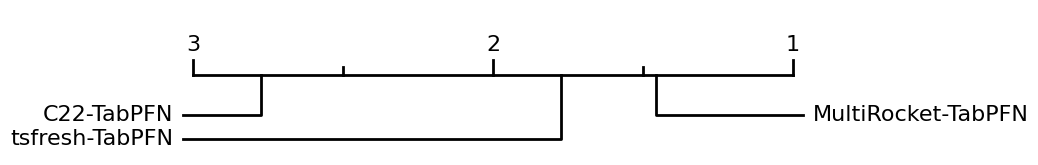

In [50]:
fig = critical_difference_diagram(
    metrics=combined,
    test='wilcoxon',
    alpha=0.05
)

In [51]:
fig.savefig('figs/tsc_intra.pdf', bbox_inches='tight')

/tmp/ipykernel_3153590/1147299975.py:1: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig('figs/tsc_intra.pdf', bbox_inches='tight')


In [52]:
UNI_BASE = "/home/gcmerlin/exp/TS2TabPFN/tsc/results/Univariate"
MULTI_BASE = "/home/gcmerlin/exp/TS2TabPFN/tsc/results/Multivariate"

# Pegar arquivos
uni_files = glob.glob(UNI_BASE + "/*_accuracy.csv")
multi_files = glob.glob(MULTI_BASE + "/*_accuracy.csv")

def extract_model_name(path):
    return os.path.basename(path).replace("_accuracy.csv", "")

uni_models = {extract_model_name(f): f for f in uni_files}
multi_models = {extract_model_name(f): f for f in multi_files}

# Interseção
common_models = sorted(set(uni_models) & set(multi_models))

# --------------------------------------------------
# DICT FINAL (o que você quer)
# --------------------------------------------------

model_files = {
    model: [
        uni_models[model],
        multi_models[model],
    ]
    for model in common_models
}

model_files['MultiROCKET-TabPFN'] = '../../tsc/results/Tab_multi.csv'

metric_name = "accuracy"
lower_better = False

In [53]:
results = {}

for model_name, paths in model_files.items():

    # 🔒 Garantir que sempre seja lista
    if isinstance(paths, str):
        paths = [paths]

    model_series_list = []

    for path in paths:

        df = pd.read_csv(path, index_col=0)
        df.index = df.index.astype(str)
        df = df.select_dtypes(include="number")

        mean_scores = df.mean(axis=1)
        model_series_list.append(mean_scores)

    combined_model_scores = pd.concat(model_series_list)

    results[model_name] = combined_model_scores


combined = pd.concat(results, axis=1)
combined = combined.dropna()

print("Datasets usados:", len(combined))

Datasets usados: 134


Index(['DrCIF', 'HC1', 'Arsenal', 'ROCKET', 'MultiROCKET-TabPFN', 'HC2'], dtype='object')
[0, 1, 2, 3]
[4, 5]


/home/gcmerlin/miniconda3/envs/tabs/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/home/gcmerlin/miniconda3/envs/tabs/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


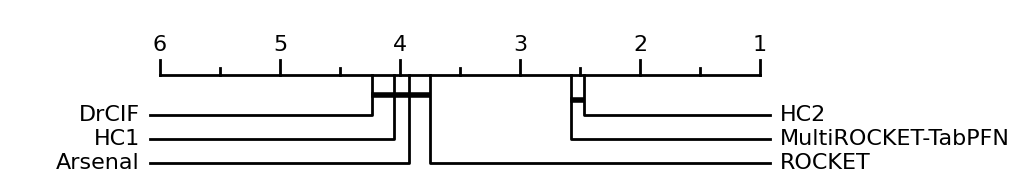

In [54]:
combined = combined[['DrCIF','Arsenal', 'HC1', 'ROCKET', 'MultiROCKET-TabPFN', 'HC2']]

fig = critical_difference_diagram(
    metrics=combined,
    test='wilcoxon',
    alpha=0.05
)

In [55]:
fig.savefig('figs/tsc_bench.pdf', bbox_inches='tight')

/tmp/ipykernel_3153590/217241361.py:1: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig('figs/tsc_bench.pdf', bbox_inches='tight')


Processing HC2, MultiROCKET-TabPFN:   0%|          | 0/3 [00:00<?, ?it/s]   


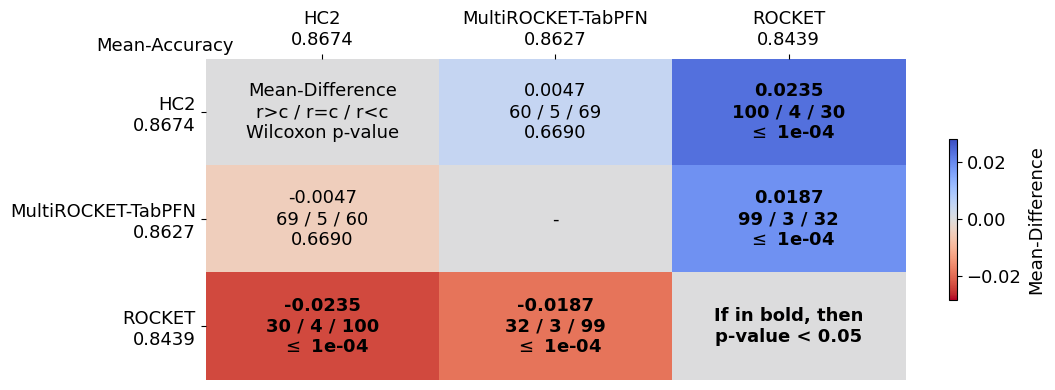

In [56]:
combined = combined[['ROCKET', 'MultiROCKET-TabPFN', 'HC2']]

fig = generate_mcm(
    metrics=combined,
    colormap='coolwarm_r',
    font_size=13
)
fig.show()

In [57]:
fig.savefig('figs/tsc_mcm.pdf', bbox_inches='tight')